In [1]:
from datasets import load_dataset, Audio
from huggingface_hub import login
# login(token="")

ds = load_dataset("changelinglab/easycall-dysarthria")
ds = ds.cast_column("audio", Audio(sampling_rate=16000))

In [2]:
print(ds)

DatasetDict({
    test: Dataset({
        features: ['audio', 'filename', 'speaker', 'text', 'dysarthria_severity'],
        num_rows: 5213
    })
    train: Dataset({
        features: ['audio', 'filename', 'speaker', 'text', 'dysarthria_severity'],
        num_rows: 11901
    })
    validation: Dataset({
        features: ['audio', 'filename', 'speaker', 'text', 'dysarthria_severity'],
        num_rows: 4272
    })
})


In [3]:
sample = ds["train"][0]

print(sample.keys())
print(sample)

dict_keys(['audio', 'filename', 'speaker', 'text', 'dysarthria_severity'])
{'audio': {'path': 'f10_02_Scendi.wav', 'array': array([0., 0., 0., ..., 0., 0., 0.], shape=(33600,)), 'sampling_rate': 16000}, 'filename': 'f10_02_Scendi.wav', 'speaker': 'f10', 'text': 'scendi', 'dysarthria_severity': '3'}


Print top n commands

In [4]:
from collections import Counter

commands = [x["text"] for x in ds["train"]]

counter = Counter(commands)

print("Top 30 commands:\n")

for cmd, count in counter.most_common(30):
    print(f"{cmd:30} {count}")

Top 30 commands:

aggiungi ai preferiti          178
deseleziona                    178
chiama emergenza               178
chiamata                       178
bue                            178
otto                           178
sette                          178
nuovo contatto                 178
sei                            177
seleziona                      177
uno                            177
vai alla pagina principale     177
attiva vivavoce                177
quattro                        177
vai nel registro chiamate      177
chiudi                         177
tra                            177
cancella contatto              177
scesi                          177
muto                           177
tastiera                       177
due                            177
apri                           177
chiudi rubrica                 177
no                             177
tre                            177
vai nei preferiti              177
preferiti                      177
ag

In [5]:
speakers = set(x["speaker"] for x in ds["train"])

print("Number of speakers:", len(speakers))
print(speakers)

Number of speakers: 31
{'f03', 'f08', 'f01', 'fc08', 'mc12', 'mc01', 'f10', 'fc09', 'm08', 'm14', 'm04', 'm06', 'mc10', 'mc06', 'm07', 'm01', 'mc02', 'm18', 'fc02', 'm03', 'm02', 'm15', 'f05', 'm19', 'mc13', 'f02', 'fc06', 'mc03', 'm20', 'fc01', 'mc09'}


In [6]:
sample = ds["train"][0]

print(sample["text"])
print(sample["speaker"])
print(sample["dysarthria_severity"])
print(sample["audio"]["sampling_rate"])

scendi
f10
3
16000


In [8]:
from IPython.display import Audio, display

def play_sample(ds, split="train", idx=0):
    sample = ds[split][idx]
    
    audio = sample["audio"]["array"]
    sr = sample["audio"]["sampling_rate"]
    
    print(f"Split: {split}")
    print(f"Index: {idx}")
    print(f"Speaker: {sample['speaker']}")
    print(f"Text: {sample['text']}")
    print(f"Severity: {sample['dysarthria_severity']}")
    
    display(Audio(audio, rate=sr))

In [9]:
play_sample(ds, "train", 15)

Split: train
Index: 15
Speaker: f10
Text: vai alla tastiera
Severity: 3


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from IPython.display import Audio, display

def inspect_sample(ds, split="train", idx=0):
    
    sample = ds[split][idx]
    
    audio = sample["audio"]["array"]
    sr = sample["audio"]["sampling_rate"]
    
    print(f"Split: {split}")
    print(f"Index: {idx}")
    print(f"Speaker: {sample['speaker']}")
    print(f"Text: {sample['text']}")
    print(f"Dysarthria severity: {sample['dysarthria_severity']}")
    print(f"Duration: {len(audio)/sr:.2f} seconds")
    
    # play audio
    display(Audio(audio, rate=sr))
    
    # waveform
    plt.figure(figsize=(12,4))
    librosa.display.waveshow(audio, sr=sr)
    plt.title("Waveform")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.show()
    
    # spectrogram
    S = librosa.stft(audio)
    S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)
    
    plt.figure(figsize=(12,4))
    librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="hz")
    plt.colorbar(format="%+2.0f dB")
    plt.title("Spectrogram")
    plt.show()

Split: train
Index: 0
Speaker: f10
Text: scendi
Dysarthria severity: 3
Duration: 2.10 seconds


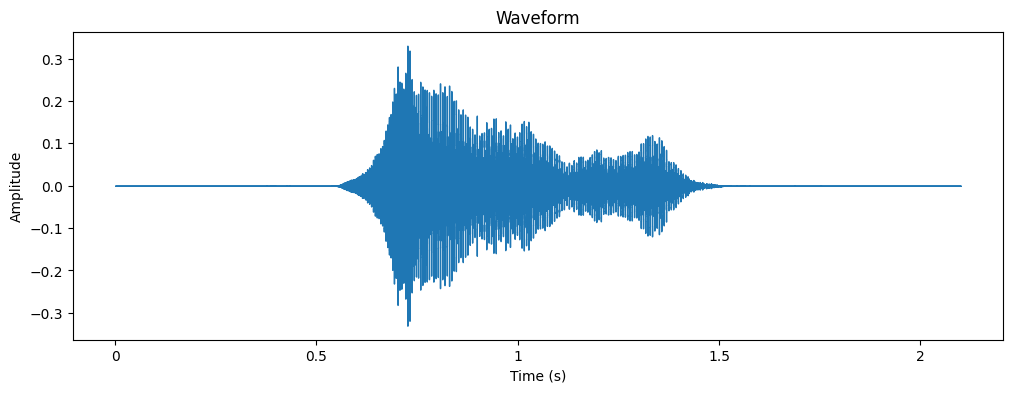

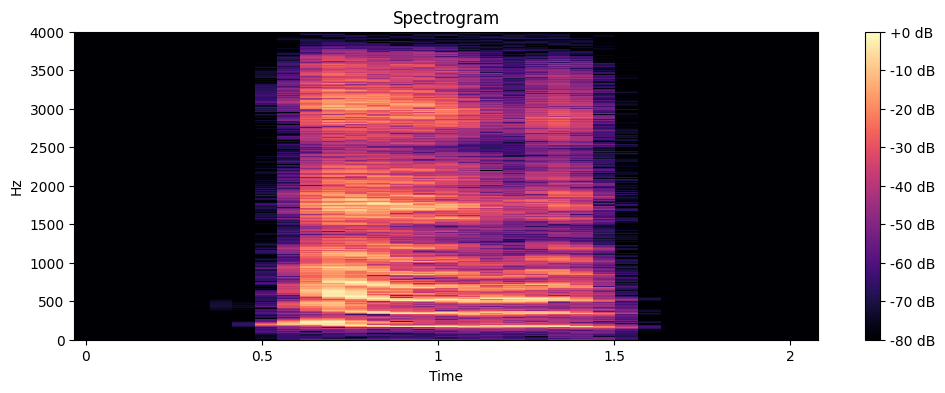

In [13]:
inspect_sample(ds, "train", 0)

In [15]:
from datasets import load_dataset

ds = load_dataset("changelinglab/easycall-dysarthria")

In [16]:
print(ds)

DatasetDict({
    test: Dataset({
        features: ['audio', 'filename', 'speaker', 'text', 'dysarthria_severity'],
        num_rows: 5213
    })
    train: Dataset({
        features: ['audio', 'filename', 'speaker', 'text', 'dysarthria_severity'],
        num_rows: 11901
    })
    validation: Dataset({
        features: ['audio', 'filename', 'speaker', 'text', 'dysarthria_severity'],
        num_rows: 4272
    })
})


In [17]:
print(ds["train"].features)

{'audio': Audio(sampling_rate=None, mono=True, decode=True, id=None), 'filename': Value(dtype='string', id=None), 'speaker': Value(dtype='string', id=None), 'text': Value(dtype='string', id=None), 'dysarthria_severity': Value(dtype='string', id=None)}


In [2]:
severity1 = ds["train"].filter(
    lambda x: x["dysarthria_severity"] == "1"
)

Filter:   0%|          | 0/11901 [00:00<?, ? examples/s]

In [3]:
print(len(severity1))

3588


In [27]:
for i in range(5):
    print("Speaker:", severity1[i]["speaker"])
    print("GT:", severity1[i]["text"])
    print("Severity:", severity1[i]["dysarthria_severity"])
    print()

Speaker: m04
GT: uno
Severity: 1

Speaker: m04
GT: rubrica
Severity: 1

Speaker: m04
GT: rimuovi
Severity: 1

Speaker: m04
GT: vai nel registro chiamate
Severity: 1

Speaker: m04
GT: salva
Severity: 1



In [28]:
from collections import Counter

Counter(x["text"] for x in severity1)

Counter({'uno': 53,
         'rubrica': 53,
         'rimuovi': 53,
         'vai nel registro chiamate': 53,
         'salva': 53,
         'chiudi rubrica': 53,
         'si': 53,
         'nave': 53,
         'muovi': 53,
         'chiama ultimo numero': 53,
         'sei': 53,
         'apri': 53,
         'sotto': 53,
         'aggiungi ai preferiti': 53,
         'zelo': 53,
         'scendi': 53,
         'vai alla tastiera': 53,
         'disattiva vivavoce': 53,
         'raggiungi': 53,
         'tra': 53,
         'chiudi applicazione': 53,
         'bue': 53,
         'cancella tutto': 53,
         'termina chiamata': 53,
         'aggiungi': 53,
         'scorri verso il basso': 53,
         'quattro': 53,
         'cancella contatto': 53,
         'no': 53,
         'nove': 53,
         'seleziona': 53,
         'richiama': 53,
         'fai una telefonata': 53,
         'deseleziona': 53,
         'chiama': 53,
         'sopra': 53,
         'sette': 53,
         'nuovo 

In [4]:
from collections import Counter

commands = Counter(severity1["text"])

print("Unique commands:", len(commands))
print(commands)

Unique commands: 71
Counter({'uno': 53, 'rubrica': 53, 'rimuovi': 53, 'vai nel registro chiamate': 53, 'salva': 53, 'chiudi rubrica': 53, 'si': 53, 'nave': 53, 'muovi': 53, 'chiama ultimo numero': 53, 'sei': 53, 'apri': 53, 'sotto': 53, 'aggiungi ai preferiti': 53, 'zelo': 53, 'scendi': 53, 'vai alla tastiera': 53, 'disattiva vivavoce': 53, 'raggiungi': 53, 'tra': 53, 'chiudi applicazione': 53, 'bue': 53, 'cancella tutto': 53, 'termina chiamata': 53, 'aggiungi': 53, 'scorri verso il basso': 53, 'quattro': 53, 'cancella contatto': 53, 'no': 53, 'nove': 53, 'seleziona': 53, 'richiama': 53, 'fai una telefonata': 53, 'deseleziona': 53, 'chiama': 53, 'sopra': 53, 'sette': 53, 'nuovo contatto': 53, 'chiudi': 53, 'vai alla pagina principale': 53, 'zero': 53, 'stop': 53, 'due': 53, 'vivavoce': 53, 'tre': 53, 'cinque': 53, 'scesi': 53, 'cancella': 53, 'chiama emergenza': 53, 'preferiti': 53, 'sali': 53, 'top': 53, 'indietro': 53, 'otto': 53, 'attiva vivavoce': 53, 'muto': 53, 'terminare': 53, '

In [5]:
for cmd, count in commands.most_common():
    print(cmd, count)

uno 53
rubrica 53
rimuovi 53
vai nel registro chiamate 53
salva 53
chiudi rubrica 53
si 53
nave 53
muovi 53
chiama ultimo numero 53
sei 53
apri 53
sotto 53
aggiungi ai preferiti 53
zelo 53
scendi 53
vai alla tastiera 53
disattiva vivavoce 53
raggiungi 53
tra 53
chiudi applicazione 53
bue 53
cancella tutto 53
termina chiamata 53
aggiungi 53
scorri verso il basso 53
quattro 53
cancella contatto 53
no 53
nove 53
seleziona 53
richiama 53
fai una telefonata 53
deseleziona 53
chiama 53
sopra 53
sette 53
nuovo contatto 53
chiudi 53
vai alla pagina principale 53
zero 53
stop 53
due 53
vivavoce 53
tre 53
cinque 53
scesi 53
cancella 53
chiama emergenza 53
preferiti 53
sali 53
top 53
indietro 53
otto 53
attiva vivavoce 53
muto 53
terminare 53
chiamata 53
mali 53
tastiera 53
sezione 53
vai nei preferiti 53
vai nella rubrica 53
cella 53
apri rubrica 1 30
scorri verso l alto 30
apri rubrica 2 30
apri rubrica 3 30
esci da rubrica 30
apri rubrica 23
scorri verso l’alto 23


In [6]:
from collections import Counter

speaker_counts = Counter(severity1["speaker"])
print(speaker_counts)

Counter({'f05': 414, 'f08': 414, 'm18': 414, 'm20': 414, 'm15': 414, 'm04': 396, 'f03': 396, 'm02': 396, 'f01': 330})


In [8]:
sample = severity1[0]

print(sample["audio"]["sampling_rate"])
print(len(sample["audio"]["array"]))

16000
26240


In [9]:
durations = []

for s in severity1:
    audio = s["audio"]
    dur = len(audio["array"]) / audio["sampling_rate"]
    durations.append(dur)

print("min:", min(durations))
print("max:", max(durations))
print("avg:", sum(durations)/len(durations))

min: 0.02
max: 20.5
avg: 2.3955685618729095


In [10]:
sorted(commands.items(), key=lambda x: x[1], reverse=True)

[('uno', 53),
 ('rubrica', 53),
 ('rimuovi', 53),
 ('vai nel registro chiamate', 53),
 ('salva', 53),
 ('chiudi rubrica', 53),
 ('si', 53),
 ('nave', 53),
 ('muovi', 53),
 ('chiama ultimo numero', 53),
 ('sei', 53),
 ('apri', 53),
 ('sotto', 53),
 ('aggiungi ai preferiti', 53),
 ('zelo', 53),
 ('scendi', 53),
 ('vai alla tastiera', 53),
 ('disattiva vivavoce', 53),
 ('raggiungi', 53),
 ('tra', 53),
 ('chiudi applicazione', 53),
 ('bue', 53),
 ('cancella tutto', 53),
 ('termina chiamata', 53),
 ('aggiungi', 53),
 ('scorri verso il basso', 53),
 ('quattro', 53),
 ('cancella contatto', 53),
 ('no', 53),
 ('nove', 53),
 ('seleziona', 53),
 ('richiama', 53),
 ('fai una telefonata', 53),
 ('deseleziona', 53),
 ('chiama', 53),
 ('sopra', 53),
 ('sette', 53),
 ('nuovo contatto', 53),
 ('chiudi', 53),
 ('vai alla pagina principale', 53),
 ('zero', 53),
 ('stop', 53),
 ('due', 53),
 ('vivavoce', 53),
 ('tre', 53),
 ('cinque', 53),
 ('scesi', 53),
 ('cancella', 53),
 ('chiama emergenza', 53),
 ('

In [23]:
from easycall_loader import EasyCallDataset

dataset = EasyCallDataset(
    split="train",
    severity="1",
    speaker="f05"
)

print(len(dataset))

sample = dataset[0]

print(sample["transcript"])
print(sample["audio"].shape)

414
top
(20480,)


In [24]:
import whisper

model = whisper.load_model("turbo")

# dataset = EasyCallDataset(
#     split="train",
#     severity="1",
#     speaker="f05"
# )

# for i in range(5):

#     sample = dataset[i]

#     result = model.transcribe(
#         sample["audio"],
#         language="it"
#     )

#     print("GT :", sample["transcript"])
#     print("ASR:", result["text"])
#     print()

In [25]:
import torch
del model
torch.cuda.empty_cache()